In [6]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df["country"].head(10)

0                                        United States
1                                         South Africa
2                                                  NaN
3                                                  NaN
4                                                India
5                                                  NaN
6                                                  NaN
7    United States, Ghana, Burkina Faso, United Kin...
8                                       United Kingdom
9                                        United States
Name: country, dtype: str

In [8]:
df["country"] = df["country"].str.split(",")

In [9]:
df_country = df.explode("country")

In [10]:
df_country["country"] = df_country["country"].str.strip()

In [11]:
country_counts = df_country["country"].value_counts()

country_counts.head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

In [12]:
df["type"].head(10)

0      Movie
1    TV Show
2    TV Show
3    TV Show
4    TV Show
5    TV Show
6      Movie
7      Movie
8    TV Show
9      Movie
Name: type, dtype: str

In [13]:
df["type"] = df["type"].str.strip()

In [14]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [15]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [16]:
df[df["rating"] == "74 min"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,[United States],"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."


In [17]:
df[df["rating"] == "84 min"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,[United States],"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...


In [18]:
df[df["rating"] == "66 min"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,[United States],"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [19]:
df[df["rating"].isin(["74 min", "84 min", "66 min"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,[United States],"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,[United States],"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,[United States],"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [20]:
df["duration"].value_counts().head(20)

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
92 min        129
102 min       122
98 min        120
99 min        118
88 min        116
101 min       116
103 min       114
106 min       111
100 min       108
89 min        106
Name: count, dtype: int64

In [21]:
mask = df["rating"].isin(["74 min", "84 min", "66 min"])

In [22]:
df.loc[mask, "duration"] = df.loc[mask, "rating"]

In [23]:
df.loc[mask, "rating"] = None

In [24]:
df.loc[mask, ["title", "rating", "duration"]]

,title,rating,duration
5541,Louis C.K. 2017,NaN,74 min
5794,Louis C.K.: Hilarious,NaN,84 min
5813,Louis C.K.: Live at the Comedy Store,NaN,66 min


In [25]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [26]:
df["director"].isnull().sum() / len(df) * 100

np.float64(29.908027705234474)

In [27]:
df["country"].isnull().head()

0    False
1    False
2     True
3     True
4    False
Name: country, dtype: bool

In [28]:
df[df["country"].isnull()].head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."


In [29]:
df.groupby(["release_year", "type"]).size()

release_year  type   
1925          TV Show      1
1942          Movie        2
1943          Movie        3
1944          Movie        3
1945          Movie        3
                        ... 
2019          TV Show    397
2020          Movie      517
              TV Show    436
2021          Movie      277
              TV Show    315
Length: 119, dtype: int64

In [30]:
year_type = df.groupby(["release_year", "type"]).size().unstack()

In [31]:
year_type.tail(10)

type,Movie,TV Show
release_year,,
2012,173.0,64.0
2013,225.0,63.0
2014,264.0,88.0
2015,398.0,162.0
2016,658.0,244.0
2017,767.0,265.0
2018,767.0,380.0
2019,633.0,397.0
2020,517.0,436.0


In [32]:
import matplotlib.pyplot as plt

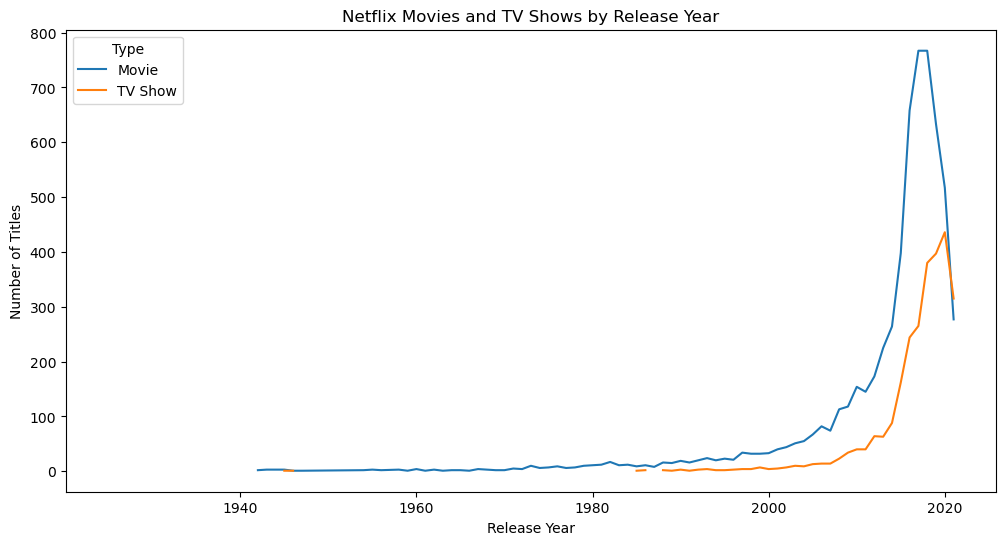

In [33]:
year_type.plot(kind="line", figsize=(12,6))

plt.title("Netflix Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Type")
plt.show()

In [34]:
recent_years = year_type.loc[2000:2021]

recent_years

type,Movie,TV Show
release_year,,
2000,33.0,4.0
2001,40.0,5.0
2002,44.0,7.0
2003,51.0,10.0
2004,55.0,9.0
2005,67.0,13.0
2006,82.0,14.0
2007,74.0,14.0
2008,113.0,23.0


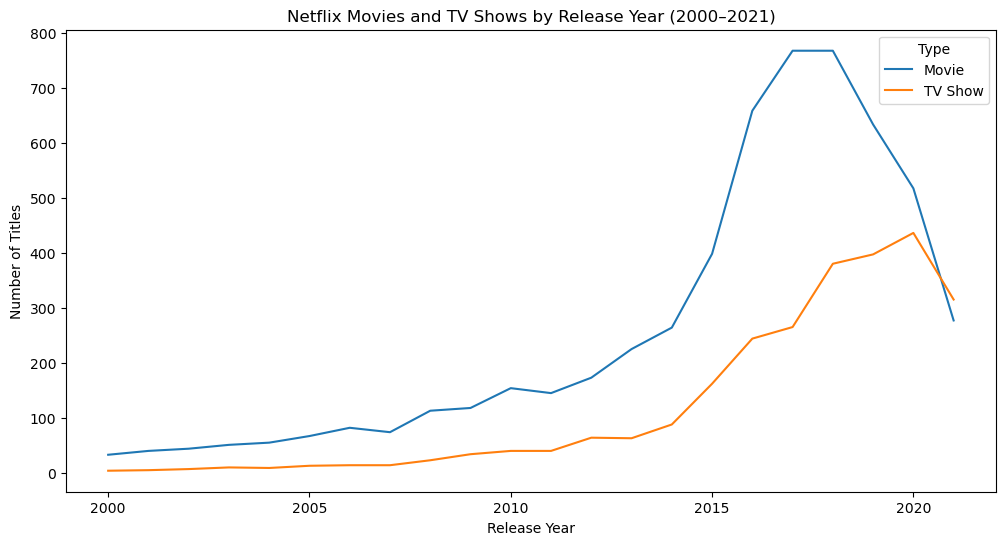

In [35]:
recent_years.plot(kind="line", figsize=(12,6))

plt.title("Netflix Movies and TV Shows by Release Year (2000–2021)")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Type")
plt.show()

In [36]:
movies = df[df["type"] == "Movie"].copy()

In [37]:
movies["duration_min"] = movies["duration"].str.replace(" min", "", regex=False)

In [38]:
movies["duration_min"] = pd.to_numeric(movies["duration_min"], errors="coerce")

In [39]:
movies["duration_min"].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

In [40]:
movies["duration_category"] = pd.cut(
    movies["duration_min"],
    bins=[0, 60, 90, 120, float("inf")],
    labels=["Under 60", "60-90", "90-120", "Over 120"]
)

In [41]:
movies["duration_category"].value_counts().sort_index()

duration_category
Under 60     487
60-90       1506
90-120      2996
Over 120    1142
Name: count, dtype: int64

In [42]:
avg_duration_by_year = movies.groupby("release_year")["duration_min"].mean()

In [43]:
avg_duration_by_year.loc[2000:2021]

release_year
2000    111.060606
2001    115.400000
2002    119.545455
2003    116.274510
2004    114.327273
2005    113.925373
2006    113.012195
2007    113.229730
2008    106.238938
2009    108.949153
2010    104.324675
2011    102.868966
2012    100.757225
2013     98.048889
2014    100.261364
2015     99.429648
2016     95.360182
2017     95.507171
2018     96.185137
2019     93.466035
2020     92.141199
2021     96.444043
Name: duration_min, dtype: float64

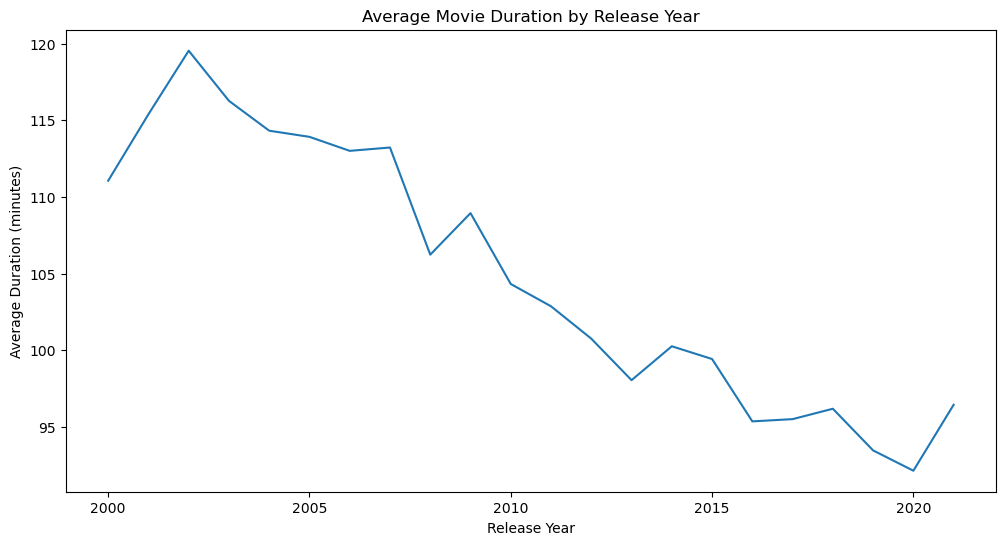

In [44]:
avg_duration_by_year.loc[2000:2021].plot(
    kind="line",
    figsize=(12, 6)
)

plt.title("Average Movie Duration by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Duration (minutes)")
plt.show()

In [45]:
country_type = df_country.groupby(["country", "type"])["show_id"].count()

In [46]:
df[(df["type"] == "Movie") & (df["release_year"] > 2020)][
    ["title", "release_year", "type"]
].head(10)

,title,release_year,type
6,My Little Pony: A New Generation,2021,Movie
9,The Starling,2021,Movie
12,Je Suis Karl,2021,Movie
13,Confessions of an Invisible Girl,2021,Movie
18,Intrusion,2021,Movie
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,2021,Movie
30,Ankahi Kahaniya,2021,Movie
35,The Father Who Moves Mountains,2021,Movie
36,The Stronghold,2021,Movie
45,My Heroes Were Cowboys,2021,Movie


In [47]:
df_country[['show_id', 'country']]

,show_id,country
0,s1,United States
1,s2,South Africa
2,s3,NaN
3,s4,NaN
4,s5,India
...,...,...
8802,s8803,United States
8803,s8804,NaN
8804,s8805,United States
8805,s8806,United States


In [48]:
df_country[['show_id', 'country']].head(20)

,show_id,country
0,s1,United States
1,s2,South Africa
2,s3,NaN
3,s4,NaN
4,s5,India
5,s6,NaN
6,s7,NaN
7,s8,United States
7,s8,Ghana
7,s8,Burkina Faso


In [49]:
df_country.shape

(10850, 12)

In [50]:
country_table = df_country[['show_id', 'country']].dropna(subset=['country'])

In [51]:
country_table.shape

(10019, 2)

In [52]:
country_table.head(15)

,show_id,country
0,s1,United States
1,s2,South Africa
4,s5,India
7,s8,United States
7,s8,Ghana
7,s8,Burkina Faso
7,s8,United Kingdom
7,s8,Germany
7,s8,Ethiopia
8,s9,United Kingdom


In [53]:
country_table = country_table.reset_index(drop=True)

In [54]:
country_table.head(15)

,show_id,country
0,s1,United States
1,s2,South Africa
2,s5,India
3,s8,United States
4,s8,Ghana
5,s8,Burkina Faso
6,s8,United Kingdom
7,s8,Germany
8,s8,Ethiopia
9,s9,United Kingdom


In [68]:
"""import pymysql
from sqlalchemy import create_engine, URL"""

'import pymysql\nfrom sqlalchemy import create_engine, URL'

In [67]:
'''import pymysql

connection = pymysql.connect(
    host="192.168.173.144",
    user="python_user",
    password="Q$Vz4v$MH9#;Dgy",
    database="netflix",
    port=3306
)

print("Connected!")'''

'import pymysql\n\nconnection = pymysql.connect(\n    host="192.168.173.144",\n    user="python_user",\n    password="Q$Vz4v$MH9#;Dgy",\n    database="netflix",\n    port=3306\n)\n\nprint("Connected!")'

In [57]:
import sys
print(sys.version)

3.14.2 (main, Jun  9 2026, 08:15:54) [Clang 23.0.0git (https:/github.com/llvm/llvm-project e5927fecf8a6ce89e1a4eac5b8


In [58]:
import platform
print(platform.platform())

Emscripten-5.0.3-wasm32-32bit


In [59]:
country_table.to_csv("/home/pyodide/netflix_country.csv", index=False)

In [60]:
print(country_table.shape)
print(country_table.head())

(10019, 2)
  show_id        country
0      s1  United States
1      s2   South Africa
2      s5          India
3      s8  United States
4      s8          Ghana


In [61]:
import os
print(os.path.exists("/home/pyodide/netflix_country.csv"))

True


In [62]:
print("/home/pyodide/netflix_country.csv")

/home/pyodide/netflix_country.csv


In [63]:
from IPython.display import FileLink

FileLink("/home/pyodide/netflix_country.csv")

/home/pyodide/netflix_country.csv

In [64]:
import os

os.listdir("/home/pyodide")

['default.profraw', '.ipython', '.matplotlib', 'netflix_country.csv']

In [69]:
import os

In [70]:
os.path.exists("/home/pyodide/netflix_country.csv")

True

In [76]:
from IPython.display import FileLink
FileLink("/home/pyodide/netflix_country.csv")

/home/pyodide/netflix_country.csv

In [77]:
import base64

In [78]:
data = open("/home/pyodide/netflix_country.csv", "rb").read()

In [79]:
from IPython.display import HTML

In [80]:
HTML(
    f'<a download="netflix_country.csv" '
    f'href="data:text/csv;base64,{base64.b64encode(data).decode()}">'
    f'⬇️ Download netflix_country.csv</a>'
)